In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    
    if len(files) > 0:
        
        print("\n", root)
        print("Files:", files[:10])


 /kaggle/input/datasets/raddar/chest-xrays-indiana-university
Files: ['indiana_projections.csv', 'indiana_reports.csv']

 /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized
Files: ['349_IM-1697-2001.dcm.png', '607_IM-2196-1001.dcm.png', '2832_IM-1249-2001.dcm.png', '699_IM-2263-2001.dcm.png', '1931_IM-0602-2001.dcm.png', '947_IM-2442-2001.dcm.png', '2932_IM-1335-1001.dcm.png', '2303_IM-0882-1001.dcm.png', '291_IM-1313-2001.dcm.png', '1790_IM-0515-1001.dcm.png']


In [2]:
import pandas as pd

REPORTS_PATH = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_reports.csv"
PROJECTIONS_PATH = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/indiana_projections.csv"

reports_df = pd.read_csv(REPORTS_PATH)
projections_df = pd.read_csv(PROJECTIONS_PATH)

print("Reports Shape:", reports_df.shape)
print("Projections Shape:", projections_df.shape)

Reports Shape: (3851, 8)
Projections Shape: (7466, 3)


In [3]:
print("REPORT COLUMNS")
print(reports_df.columns)

reports_df.head()

REPORT COLUMNS
Index(['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison',
       'findings', 'impression'],
      dtype='object')


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


In [4]:
print("PROJECTION COLUMNS")
print(projections_df.columns)

projections_df.head()

PROJECTION COLUMNS
Index(['uid', 'filename', 'projection'], dtype='object')


,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


In [5]:
print("REPORTS")

print(
    reports_df.isnull()
    .sum()
)

print("\nPROJECTIONS")

print(
    projections_df.isnull()
    .sum()
)

REPORTS
uid              0
MeSH             0
Problems         0
image            0
indication      86
comparison    1166
findings       514
impression      31
dtype: int64

PROJECTIONS
uid           0
filename      0
projection    0
dtype: int64


In [6]:
for col in reports_df.columns:

    print("="*50)
    print(col)
    print("="*50)

    print(
        reports_df[col]
        .iloc[0]
    )

    print()

uid
1

MeSH
normal

Problems
normal

image
Xray Chest PA and Lateral

indication
Positive TB test

comparison
None.

findings
The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pneumothorax.

impression
Normal chest x-XXXX.



In [7]:
from collections import Counter
import re

all_text = (
    reports_df["findings"]
    .fillna("")
    .str.lower()
)

keywords = [
    "pneumonia",
    "effusion",
    "atelectasis",
    "cardiomegaly",
    "edema",
    "nodule",
    "mass",
    "pneumothorax",
    "emphysema",
    "hernia",
    "normal"
]

for word in keywords:

    count = all_text.str.contains(
        word,
        na=False
    ).sum()

    print(
        f"{word}: {count}"
    )

pneumonia: 129
effusion: 2570
atelectasis: 221
cardiomegaly: 134
edema: 193
nodule: 204
mass: 134
pneumothorax: 2367
emphysema: 74
hernia: 44
normal: 2961


In [8]:
print(
    reports_df["MeSH"]
    .value_counts()
    .head(30)
)

MeSH
normal                                                         1379
No Indexing                                                      92
Lung/hypoinflation                                               44
Thoracic Vertebrae/degenerative/mild                             29
Thoracic Vertebrae/degenerative                                  23
Spine/degenerative                                               19
Spine/degenerative/mild                                          18
Cardiomegaly/mild                                                17
Spondylosis/thoracic vertebrae                                   17
Granulomatous Disease                                            16
Lung/hyperdistention                                             15
Lung/hypoinflation/mild                                           9
Lung/hypoinflation;Markings/bronchovascular                       9
Catheters, Indwelling/right                                       9
Atherosclerosis/aorta                      

In [9]:
print(
    reports_df["Problems"]
    .value_counts()
    .head(30)
)

Problems
normal                            1379
No Indexing                         92
Lung                                86
Calcified Granuloma                 84
Thoracic Vertebrae                  59
Spine                               41
Calcinosis                          39
Opacity                             35
Cardiomegaly                        29
Scoliosis                           28
Spondylosis                         20
Surgical Instruments                20
Catheters, Indwelling               19
Osteophyte                          19
Granulomatous Disease               18
Fractures, Bone                     17
Nodule                              14
Lung;Markings                       13
Aorta, Thoracic                     12
Aorta                               12
Cicatrix                            11
Foreign Bodies                      11
Atherosclerosis                     11
Markings                            11
Implanted Medical Device            10
Calcified Granul

In [10]:
import random

for _ in range(5):

    idx = random.randint(
        0,
        len(reports_df)-1
    )

    print("="*100)

    print("MeSH:")
    print(
        reports_df.loc[idx,"MeSH"]
    )

    print("\nProblems:")
    print(
        reports_df.loc[idx,"Problems"]
    )

    print("\nFindings:")
    print(
        reports_df.loc[idx,"findings"]
    )

    print("\nImpression:")
    print(
        reports_df.loc[idx,"impression"]
    )

    print("\n")

MeSH:
normal

Problems:
normal

Findings:
nan

Impression:
Comparison XXXX, XXXX Clear lungs. No effusions. Unremarkable mediastinal contour. No acute cardiopulmonary abnormality identified.. Stable chest.


MeSH:
Opacity/lung/base/right/reticular/multiple;Lung/hypoinflation;Pulmonary Atelectasis/base/right

Problems:
Opacity;Lung;Pulmonary Atelectasis

Findings:
nan

Impression:
Anticipated senescent changes with grossly clear lungs. No effusions or CHF identified. A few scant reticular opacities in right lung base XXXX hypoventilation and foci of subsegmental atelectasis. No XXXX acute abnormalities since the previous chest radiograph.


MeSH:
normal

Problems:
normal

Findings:
nan

Impression:
Heart size is normal the lungs are clear


MeSH:
Calcinosis/abdomen/left/severe

Problems:
Calcinosis

Findings:
nan

Impression:
[&lt;The heart size and cardiomediastinal silhouette are stable and within normal limits. Pulmonary vasculature appears normal. There is no focal air space consoli

In [54]:
diseases = [
    "pneumonia",
    "effusion",
    "pneumothorax",
    "atelectasis",
    "cardiomegaly",
    "edema",
    "nodule",
    "mass"
]

for disease in diseases:

    reports_df[disease] = (
        reports_df["MeSH"]
        .str.lower()
        .str.contains(
            disease,
            na=False
        )
    ).astype(int)

for disease in diseases:

    print(
        disease,
        reports_df[disease].sum()
    )

pneumonia 40
effusion 153
pneumothorax 26
atelectasis 315
cardiomegaly 345
edema 42
nodule 106
mass 15


In [55]:
reports_df["disease"] = "unknown"

reports_df.loc[
    reports_df["Problems"]
    .str.lower()
    .eq("normal"),
    "disease"
] = "normal"

In [56]:
mapping = {

    "pneumonia":"pneumonia",
    "effusion":"effusion",
    "pneumothorax":"pneumothorax",
    "atelectasis":"atelectasis",
    "cardiomegaly":"cardiomegaly",
    "edema":"edema",
    "nodule":"nodule",
    "mass":"mass"
}

for disease in mapping:

    mask = reports_df[disease] == 1

    reports_df.loc[
        mask,
        "disease"
    ] = disease

In [57]:
print(
    reports_df["disease"]
    .value_counts()
)

disease
unknown         1650
normal          1379
cardiomegaly     306
atelectasis      251
nodule           104
effusion          61
edema             41
pneumonia         29
pneumothorax      15
mass              15
Name: count, dtype: int64


In [58]:
known_classes = [
    "normal",
    "cardiomegaly",
    "atelectasis",
    "nodule"
]

known_df = reports_df[
    reports_df["disease"].isin(
        known_classes
    )
].copy()

unknown_df = reports_df[
    ~reports_df["disease"].isin(
        known_classes
    )
].copy()

print("KNOWN")
print(
    known_df["disease"]
    .value_counts()
)

print("\nUNKNOWN")
print(
    unknown_df["disease"]
    .value_counts()
)

KNOWN
disease
normal          1379
cardiomegaly     306
atelectasis      251
nodule           104
Name: count, dtype: int64

UNKNOWN
disease
unknown         1650
effusion          61
edema             41
pneumonia         29
pneumothorax      15
mass              15
Name: count, dtype: int64


In [59]:
label_map = {

    "normal":0,
    "cardiomegaly":1,
    "atelectasis":2,
    "nodule":3
}

known_df["label"] = (
    known_df["disease"]
    .map(label_map)
)

known_df["label"].value_counts()

label
0    1379
1     306
2     251
3     104
Name: count, dtype: int64

In [60]:
merged_df = projections_df.merge(
    known_df,
    on="uid",
    how="inner"
)

merged_df = merged_df[
    merged_df["projection"]
    == "Frontal"
].copy()

print(
    merged_df.shape
)

merged_df.head()

(2027, 20)


,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression,label,pneumonia,effusion,pneumothorax,atelectasis,cardiomegaly,edema,nodule,mass,disease
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,0,0,0,0,0,0,0,0,0,normal
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,1,0,0,0,0,1,0,0,0,cardiomegaly
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",0,0,0,0,0,0,0,0,0,normal
6,6,6_IM-2192-1001.dcm.png,Frontal,normal,normal,"PA and Lateral Chest. XXXX, XXXX at XXXX",Evaluate for infection,"XXXX, XXXX",Heart size and mediastinal contour are within ...,No acute cardiopulmonary findings.,0,0,0,0,0,0,0,0,0,normal
8,7,7_IM-2263-1001.dcm.png,Frontal,Pulmonary Atelectasis/base;Spondylosis/thoraci...,Pulmonary Atelectasis;Spondylosis;Arthritis,Xray Chest PA and Lateral,Preop lumbar surgery,"XXXX, XXXX",The cardiac contours are normal. XXXX basilar ...,Basilar atelectasis. No confluent lobar consol...,2,0,0,0,1,0,0,0,0,atelectasis


In [61]:
import os

IMAGE_DIR = (
    "/kaggle/input/datasets/raddar/"
    "chest-xrays-indiana-university/"
    "images/images_normalized"
)

merged_df["image_path"] = (
    merged_df["filename"]
    .apply(
        lambda x:
        os.path.join(
            IMAGE_DIR,
            x
        )
    )
)

print(
    merged_df["image_path"]
    .apply(os.path.exists)
    .value_counts()
)

image_path
True    2027
Name: count, dtype: int64


In [62]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(

    merged_df,

    test_size=0.2,

    stratify=merged_df["label"],

    random_state=42
)

val_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    stratify=temp_df["label"],

    random_state=42
)

print(
    len(train_df),
    len(val_df),
    len(test_df)
)

1621 203 203


In [63]:
ood_df = reports_df[
    ~reports_df["disease"].isin(
        [
            "normal",
            "cardiomegaly",
            "atelectasis",
            "nodule"
        ]
    )
].copy()

ood_df = projections_df.merge(
    ood_df,
    on="uid",
    how="inner"
)

ood_df = ood_df[
    ood_df["projection"]
    == "Frontal"
].copy()

ood_df["image_path"] = (
    ood_df["filename"]
    .apply(
        lambda x:
        os.path.join(
            IMAGE_DIR,
            x
        )
    )
)

print(
    "OOD Images:",
    len(ood_df)
)

OOD Images: 1791


In [64]:
class IUXrayDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        )

        image = image.convert(
            "RGB"
        )

        if self.transform:

            image = self.transform(
                image
            )

        label = int(
            row["label"]
        )

        return image, label

In [65]:
train_dataset = IUXrayDataset(
    train_df,
    train_transform
)

val_dataset = IUXrayDataset(
    val_df,
    test_transform
)

test_dataset = IUXrayDataset(
    test_df,
    test_transform
)

ood_dataset = IUXrayDataset(
    ood_df.assign(label=0),
    test_transform
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset),
    len(ood_dataset)
)

1621 203 203 1791


In [66]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

ood_loader = DataLoader(
    ood_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [68]:
import torch.nn as nn
from torchvision import models


class DenseNetSoftmax(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = models.densenet121(
            weights="DEFAULT"
        )

        num_features = (
            self.model.classifier.in_features
        )

        self.model.classifier = nn.Sequential(

            nn.Dropout(0.3),

            nn.Linear(
                num_features,
                4
            )
        )

    def forward(
        self,
        x
    ):

        return self.model(x)

In [69]:
softmax_model = DenseNetSoftmax().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    softmax_model.parameters(),
    lr=1e-4
)

print("Model Ready")

Model Ready


In [70]:
print(
    softmax_model(
        torch.randn(
            1,
            3,
            224,
            224
        ).to(device)
    ).shape
)

torch.Size([1, 4])


In [74]:
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

def evaluate_model(
    model,
    loader
):

    model.eval()

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(
                images
            )

            preds = outputs.argmax(1)

            preds_all.extend(
                preds.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    f1 = f1_score(
        labels_all,
        preds_all,
        average="macro"
    )

    return acc, f1

In [75]:
from tqdm import tqdm

best_f1 = 0

for epoch in range(10):

    softmax_model.train()

    running_loss = 0

    for images, labels in tqdm(
        train_loader
    ):

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = softmax_model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
        )

    acc, f1 = evaluate_model(
        softmax_model,
        val_loader
    )

    print(
        f"\nEpoch {epoch+1}"
    )

    print(
        "Loss:",
        round(
            running_loss /
            len(train_loader),
            4
        )
    )

    print(
        "Val Accuracy:",
        round(acc,4)
    )

    print(
        "Macro F1:",
        round(f1,4)
    )

    if f1 > best_f1:

        best_f1 = f1

        torch.save(
            softmax_model.state_dict(),
            "best_multiclass.pth"
        )

        print(
            "Best Model Saved"
        )

100%|██████████| 51/51 [01:02<00:00,  1.22s/it]



Epoch 1
Loss: 0.6767
Val Accuracy: 0.7685
Macro F1: 0.4465
Best Model Saved


100%|██████████| 51/51 [01:02<00:00,  1.22s/it]



Epoch 2
Loss: 0.5988
Val Accuracy: 0.7734
Macro F1: 0.4536
Best Model Saved


100%|██████████| 51/51 [01:01<00:00,  1.21s/it]


...


Epoch 8
Loss: 0.2676
Val Accuracy: 0.7438
Macro F1: 0.4508


100%|██████████| 51/51 [01:00<00:00,  1.19s/it]



Epoch 9
Loss: 0.232
Val Accuracy: 0.7685
Macro F1: 0.5314


100%|██████████| 51/51 [01:00<00:00,  1.19s/it]



Epoch 10
Loss: 0.1779
Val Accuracy: 0.7635
Macro F1: 0.5595
Best Model Saved


In [76]:
softmax_model.load_state_dict(

    torch.load(
        "best_multiclass.pth",
        map_location=device
    )
)

softmax_model.eval()

print(
    "Best model loaded"
)

Best model loaded


In [77]:
test_acc, test_f1 = evaluate_model(

    softmax_model,

    test_loader
)

print("\nTEST RESULTS")

print(
    "Accuracy:",
    test_acc
)

print(
    "Macro F1:",
    test_f1
)


TEST RESULTS
Accuracy: 0.6995073891625616
Macro F1: 0.4886910088469239


In [78]:
from sklearn.metrics import (
    classification_report
)

preds_all = []
labels_all = []

softmax_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = softmax_model(
            images
        )

        preds = outputs.argmax(1)

        preds_all.extend(
            preds.cpu().numpy()
        )

        labels_all.extend(
            labels.numpy()
        )

print(

    classification_report(

        labels_all,

        preds_all,

        target_names=[

            "Normal",

            "Cardiomegaly",

            "Atelectasis",

            "Nodule"
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.86      0.79      0.82       139
Cardiomegaly       0.58      0.66      0.61        29
 Atelectasis       0.35      0.48      0.41        25
      Nodule       0.12      0.10      0.11        10

    accuracy                           0.70       203
   macro avg       0.48      0.51      0.49       203
weighted avg       0.72      0.70      0.71       203



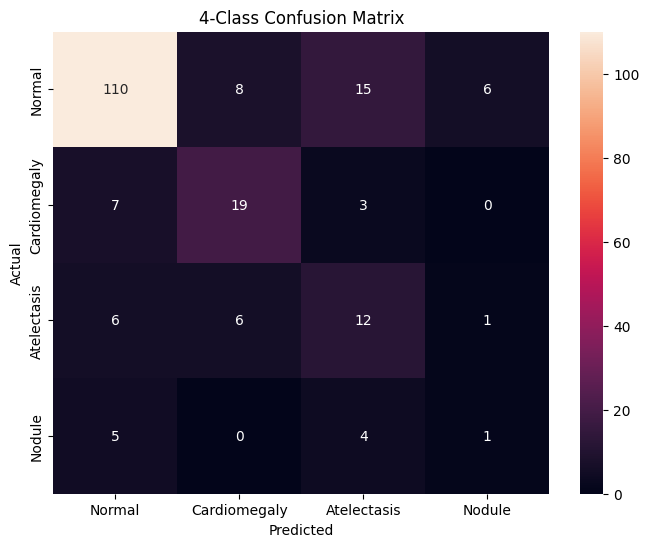

In [79]:
from sklearn.metrics import (
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(

    labels_all,

    preds_all
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=[

        "Normal",

        "Cardiomegaly",

        "Atelectasis",

        "Nodule"
    ],

    yticklabels=[

        "Normal",

        "Cardiomegaly",

        "Atelectasis",

        "Nodule"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "4-Class Confusion Matrix"
)

plt.show()

In [80]:
def enable_dropout(model):

    for m in model.modules():

        if isinstance(
            m,
            nn.Dropout
        ):
            m.train()

In [81]:
import numpy as np

def mc_dropout_predict(
    model,
    image,
    T=30
):

    model.eval()

    enable_dropout(model)

    predictions = []

    with torch.no_grad():

        for _ in range(T):

            outputs = model(
                image
            )

            probs = torch.softmax(
                outputs,
                dim=1
            )

            predictions.append(
                probs.cpu().numpy()
            )

    predictions = np.array(
        predictions
    )

    mean_prediction = np.mean(
        predictions,
        axis=0
    )

    uncertainty = np.std(
        predictions,
        axis=0
    )

    return (
        mean_prediction,
        uncertainty
    )

In [82]:
known_uncertainty = []

for i in range(200):

    image, label = test_dataset[i]

    image = image.unsqueeze(0)

    image = image.to(device)

    _, uncertainty = (

        mc_dropout_predict(

            softmax_model,

            image,

            T=30
        )
    )

    known_uncertainty.append(

        np.max(
            uncertainty
        )
    )

print(
    "Average Known Uncertainty:",
    np.mean(
        known_uncertainty
    )
)

Average Known Uncertainty: 0.045508657


In [83]:
ood_uncertainty = []

for i in range(200):

    image, label = ood_dataset[i]

    image = image.unsqueeze(0)

    image = image.to(device)

    _, uncertainty = (

        mc_dropout_predict(

            softmax_model,

            image,

            T=30
        )
    )

    ood_uncertainty.append(

        np.max(
            uncertainty
        )
    )

print(
    "Average OOD Uncertainty:",
    np.mean(
        ood_uncertainty
    )
)

Average OOD Uncertainty: 0.0548952


In [84]:
print("="*50)

print(
    "Known Mean:",
    np.mean(
        known_uncertainty
    )
)

print(
    "OOD Mean:",
    np.mean(
        ood_uncertainty
    )
)

print("="*50)

Known Mean: 0.045508657
OOD Mean: 0.0548952


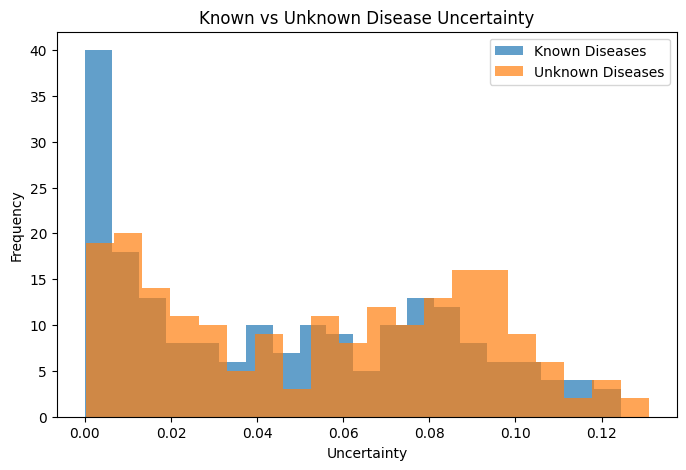

In [85]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,5)
)

plt.hist(

    known_uncertainty,

    bins=20,

    alpha=0.7,

    label="Known Diseases"
)

plt.hist(

    ood_uncertainty,

    bins=20,

    alpha=0.7,

    label="Unknown Diseases"
)

plt.xlabel(
    "Uncertainty"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.title(
    "Known vs Unknown Disease Uncertainty"
)

plt.show()

In [86]:
thresholds = [

    0.03,
    0.04,
    0.05,
    0.06,
    0.07,
    0.08
]

for th in thresholds:

    known_referred = sum(
        u > th
        for u in known_uncertainty
    )

    ood_referred = sum(
        u > th
        for u in ood_uncertainty
    )

    print(
        f"Threshold={th:.2f}"
    )

    print(
        f"Known Referred: {known_referred}/200"
    )

    print(
        f"OOD Referred: {ood_referred}/200"
    )

    print("-"*40)

Threshold=0.03
Known Referred: 115/200
OOD Referred: 130/200
----------------------------------------
Threshold=0.04
Known Referred: 101/200
OOD Referred: 121/200
----------------------------------------
Threshold=0.05
Known Referred: 90/200
OOD Referred: 111/200
----------------------------------------
Threshold=0.06
Known Referred: 74/200
OOD Referred: 98/200
----------------------------------------
Threshold=0.07
Known Referred: 63/200
OOD Referred: 82/200
----------------------------------------
Threshold=0.08
Known Referred: 43/200
OOD Referred: 64/200
----------------------------------------


In [87]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [88]:
from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.image import (
    show_cam_on_image
)

import matplotlib.pyplot as plt
import numpy as np

In [89]:
target_layers = [

    softmax_model
    .model
    .features
    [-1]
]

cam = GradCAM(

    model=softmax_model,

    target_layers=target_layers
)

In [90]:
img, label = test_dataset[0]

input_tensor = img.unsqueeze(0)

input_tensor = input_tensor.to(device)

print(
    "Actual Label:",
    label
)

Actual Label: 0


In [91]:
grayscale_cam = cam(

    input_tensor=input_tensor
)

grayscale_cam = grayscale_cam[0]

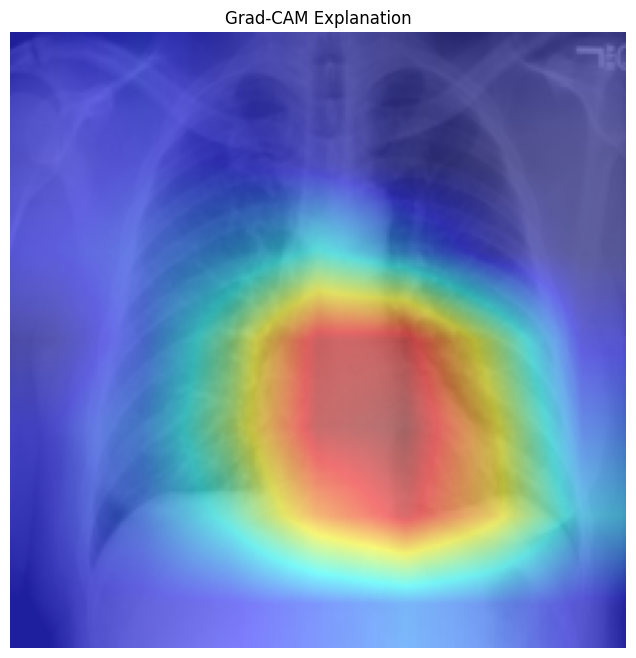

In [92]:
img_np = img.permute(

    1,
    2,
    0

).numpy()

img_np = (

    img_np *

    np.array([
        0.229,
        0.224,
        0.225
    ])

    +

    np.array([
        0.485,
        0.456,
        0.406
    ])
)

img_np = np.clip(

    img_np,

    0,

    1
)

visualization = (

    show_cam_on_image(

        img_np,

        grayscale_cam,

        use_rgb=True
    )
)

plt.figure(
    figsize=(8,8)
)

plt.imshow(
    visualization
)

plt.axis("off")

plt.title(
    "Grad-CAM Explanation"
)

plt.show()

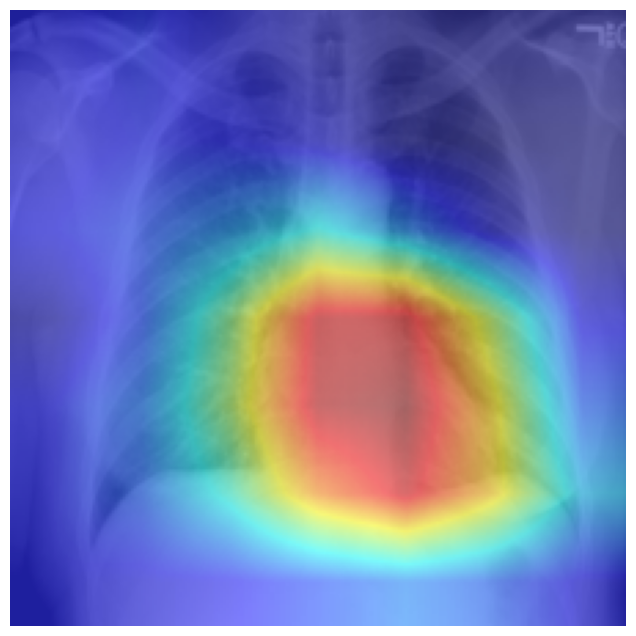

In [93]:
plt.figure(
    figsize=(8,8)
)

plt.imshow(
    visualization
)

plt.axis("off")

plt.savefig(

    "gradcam_result.png",

    bbox_inches="tight"
)

plt.show()

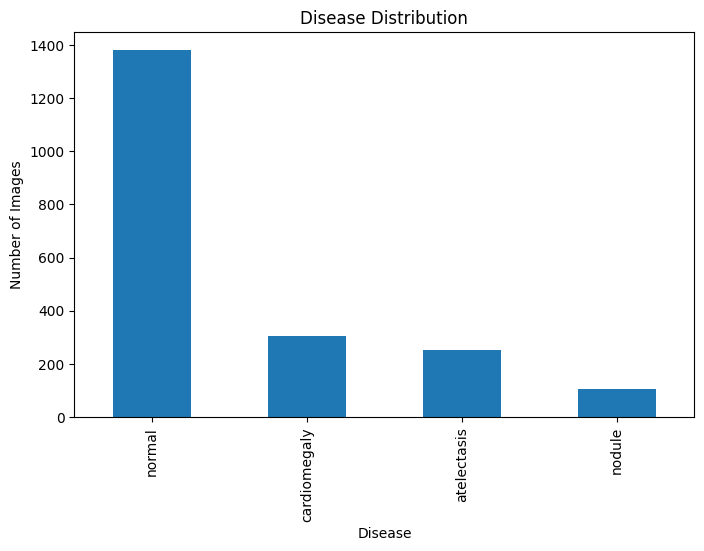

In [94]:
import matplotlib.pyplot as plt

disease_counts = known_df["disease"].value_counts()

plt.figure(figsize=(8,5))

disease_counts.plot(
    kind="bar"
)

plt.title(
    "Disease Distribution"
)

plt.xlabel(
    "Disease"
)

plt.ylabel(
    "Number of Images"
)

plt.show()

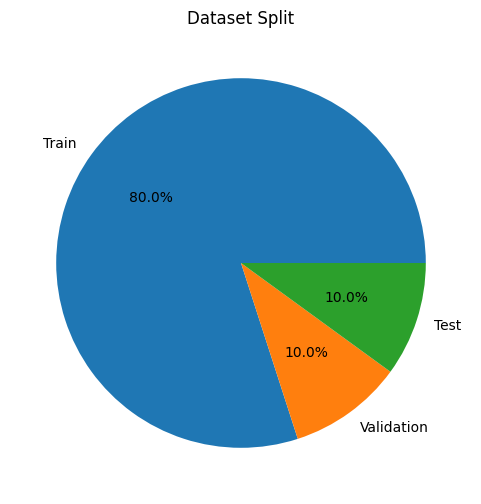

In [95]:
sizes = [

    len(train_df),

    len(val_df),

    len(test_df)
]

labels = [

    "Train",

    "Validation",

    "Test"
]

plt.figure(figsize=(6,6))

plt.pie(

    sizes,

    labels=labels,

    autopct="%1.1f%%"
)

plt.title(
    "Dataset Split"
)

plt.show()

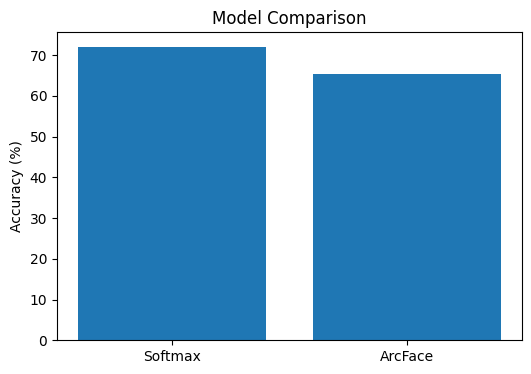

In [96]:
models = [

    "Softmax",

    "ArcFace"
]

accuracy = [

    71.99,

    65.45
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    accuracy
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Model Comparison"
)

plt.show()

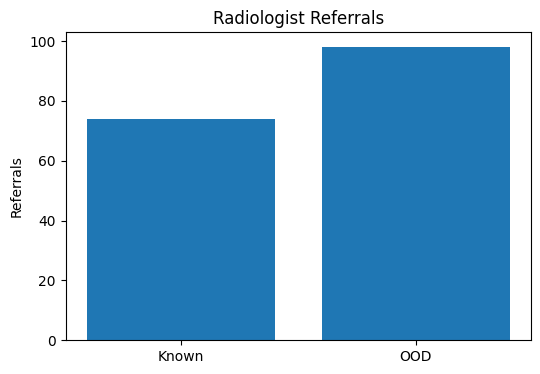

In [97]:
known_ref = 74
ood_ref = 98

plt.figure(figsize=(6,4))

plt.bar(

    ["Known","OOD"],

    [known_ref,ood_ref]
)

plt.ylabel(
    "Referrals"
)

plt.title(
    "Radiologist Referrals"
)

plt.show()

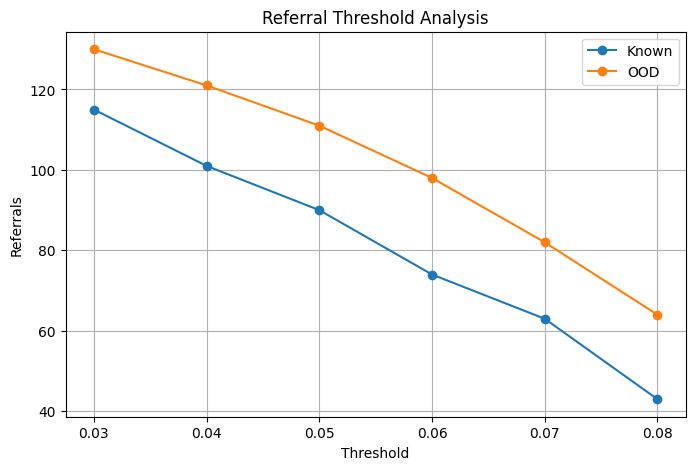

In [98]:
thresholds = [
    0.03,
    0.04,
    0.05,
    0.06,
    0.07,
    0.08
]

known = [
    115,
    101,
    90,
    74,
    63,
    43
]

ood = [
    130,
    121,
    111,
    98,
    82,
    64
]

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    known,
    marker="o",
    label="Known"
)

plt.plot(
    thresholds,
    ood,
    marker="o",
    label="OOD"
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Referrals"
)

plt.title(
    "Referral Threshold Analysis"
)

plt.legend()

plt.grid()

plt.show()